<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%94%D0%97_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install torch torchvision tqdm pandas matplotlib seaborn

Настройки и импорты.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Датасет

In [7]:
# Общие параметры
num_classes = 47  # balanced split
small_train_size = 2500   # сильно уменьшенный train для скорости
val_size = 300
batch_size_small = 16
batch_size_inception = 8  # inception тяжелее

 Сократил размер изображений, объём обучающей выборки и число эпох, чтобы ускорить обучение и уложиться в возможности Colab. Иначе перегруз по памяти и времени.
 Выборка очень маленькая

In [8]:
tfm_small = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

tfm_inception = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

ResNet, VGG, DenseNet

In [9]:
train_dataset_small = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=tfm_small
)

test_dataset_small = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=tfm_small
)

small_train_dataset = Subset(train_dataset_small, list(range(small_train_size)))

train_size_small = len(small_train_dataset) - val_size
train_subset_small, val_subset_small = random_split(
    small_train_dataset,
    [train_size_small, val_size],
    generator=torch.Generator().manual_seed(seed)
)

train_loader_small = DataLoader(train_subset_small, batch_size=batch_size_small,
                                shuffle=True, num_workers=2, pin_memory=True)
val_loader_small = DataLoader(val_subset_small, batch_size=batch_size_small,
                              shuffle=False, num_workers=2, pin_memory=True)
test_loader_small = DataLoader(test_dataset_small, batch_size=batch_size_small,
                               shuffle=False, num_workers=2, pin_memory=True)

print("Small train size:", len(train_subset_small))
print("Small val size:", len(val_subset_small))
print("Test size:", len(test_dataset_small))

Small train size: 2200
Small val size: 300
Test size: 18800


Inception v3


In [11]:
train_dataset_inception = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=tfm_inception
)

test_dataset_inception = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=tfm_inception
)

small_train_dataset_inc = Subset(train_dataset_inception, list(range(small_train_size)))

train_size_inc = len(small_train_dataset_inc) - val_size
train_subset_inc, val_subset_inc = random_split(
    small_train_dataset_inc,
    [train_size_inc, val_size],
    generator=torch.Generator().manual_seed(seed)
)

train_loader_inc = DataLoader(train_subset_inc, batch_size=batch_size_inception,
                              shuffle=True, num_workers=2, pin_memory=True)
val_loader_inc = DataLoader(val_subset_inc, batch_size=batch_size_inception,
                            shuffle=False, num_workers=2, pin_memory=True)
test_loader_inc = DataLoader(test_dataset_inception, batch_size=batch_size_inception,
                             shuffle=False, num_workers=2, pin_memory=True)

print("Inception train size:", len(train_subset_inc))
print("Inception val size:", len(val_subset_inc))
print("Test size (inc):", len(test_dataset_inception))

Inception train size: 2200
Inception val size: 300
Test size (inc): 18800


Общие функции

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X, y in tqdm(loader, leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total

def run_experiment(model, train_loader, val_loader, test_loader, epochs=1, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"epoch {epoch+1}: train={tr_loss:.4f}, val={va_loss:.4f}, acc={va_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

Модели

In [16]:
def make_resnet18():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def make_vgg16():
    m = models.vgg16(weights=None)
    m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    return m

def make_densenet161():
    m = models.densenet161(weights=None)
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_inceptionv3():

    m = models.inception_v3(weights=None, aux_logits=False, init_weights=False)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

In [17]:
experiments = {}


experiments["ResNet18"] = run_experiment(
    make_resnet18(),
    train_loader_small, val_loader_small, test_loader_small,
    epochs=1, lr=1e-3
)


experiments["VGG16"] = run_experiment(
    make_vgg16(),
    train_loader_small, val_loader_small, test_loader_small,
    epochs=1, lr=1e-3
)


experiments["DenseNet161"] = run_experiment(
    make_densenet161(),
    train_loader_small, val_loader_small, test_loader_small,
    epochs=1, lr=1e-3
)

# Inception v3
experiments["InceptionV3"] = run_experiment(
    make_inceptionv3(),
    train_loader_inc, val_loader_inc, test_loader_inc,
    epochs=1, lr=1e-3
)

epoch 1: train=2.1762, val=1.8714, acc=0.4833


epoch 1: train=4.3456, val=3.8541, acc=0.0267


epoch 1: train=2.2208, val=2.0556, acc=0.4467


epoch 1: train=3.7239, val=3.1663, acc=0.1700


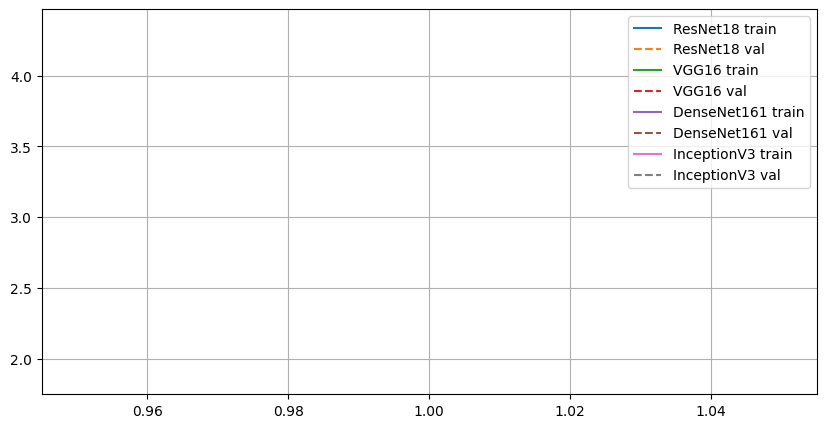

In [20]:
plt.figure(figsize=(10, 5))

for name, res in experiments.items():
    if len(res["train_losses"]) > 0:
        plt.plot(range(1, len(res["train_losses"]) + 1), res["train_losses"], label=f"{name} train")
    if len(res["val_losses"]) > 0:
        plt.plot(range(1, len(res["val_losses"]) + 1), res["val_losses"], linestyle="--", label=f"{name} val")

plt.legend()
plt.grid(True)
plt.show()

In [19]:
rows = []
for name, res in experiments.items():
    rows.append({
        "model": name,
        "best_val_acc": res["best_val_acc"],
        "test_acc": res["test_acc"],
        "test_loss": res["test_loss"]
    })

results_df = pd.DataFrame(rows).sort_values("test_acc", ascending=False)
display(results_df)
results_df.to_csv("emnist_results_conv_arch.csv", index=False)

,model,best_val_acc,test_acc,test_loss
0,ResNet18,0.483333,0.514894,1.801505
2,DenseNet161,0.446667,0.424628,2.172546
3,InceptionV3,0.170000,0.141755,3.155719
1,VGG16,0.026667,0.021277,3.851569
